# 03 — Exploratory Data Analysis (30 charts)

All charts are built from the three analytical tables (no re-cleaning here):

- `order_analytics.csv` — one row per order
- `customer_analytics.csv` — one row per customer
- `restaurant_analytics.csv` — one row per restaurant

**Structure:** Part A = 15 Matplotlib charts, Part B = 15 Seaborn charts. Every chart is also
saved to `images/eda/` so it can be dropped into the report and slides.

**Revenue definition used everywhere in this notebook:** `FinalAmount` of orders with status
*Delivered* or *Delivered Late*. Cancelled and Food-Not-Delivered orders are not counted as revenue.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

orders = pd.read_csv("../data/analytical/order_analytics.csv", parse_dates=["OrderDate"])
customers = pd.read_csv("../data/analytical/customer_analytics.csv")
restaurants = pd.read_csv("../data/analytical/restaurant_analytics.csv")

# Orders that actually reached the customer - used for revenue and delivery-time charts
delivered = orders[orders["OrderStatus"].isin(["Delivered", "Delivered Late"])].copy()

print("All orders:      ", len(orders))
print("Delivered orders:", len(delivered))
print("Date range:      ", orders["OrderDate"].min().date(), "to", orders["OrderDate"].max().date())
print("Orders with no date:", orders["OrderDate"].isna().sum(), "(left out of the time-based charts)")

All orders:       20475
Delivered orders: 13544
Date range:       2023-01-01 to 2024-12-31
Orders with no date: 1173 (left out of the time-based charts)


In [2]:
# Small helper so every chart is saved the same way
def save_chart(filename):
    plt.tight_layout()
    plt.savefig(f"../images/eda/{filename}.png", dpi=120, bbox_inches="tight")
    plt.show()

# Part A — Matplotlib (15 charts)

### Revenue

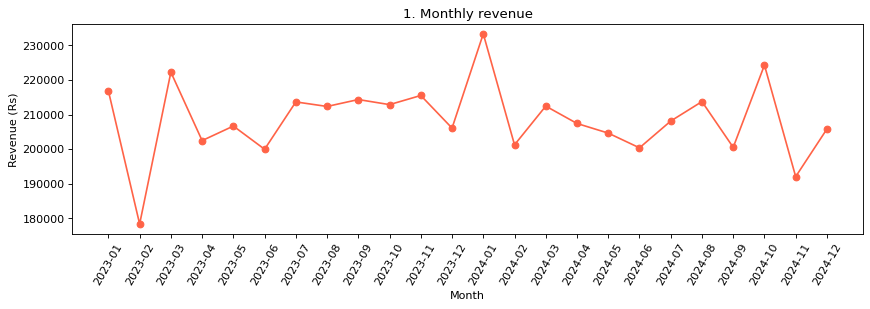

In [3]:
# 1. Monthly revenue
monthly = delivered.groupby(delivered["OrderDate"].dt.to_period("M"))["FinalAmount"].sum()

plt.figure(figsize=(11, 4))
plt.plot(monthly.index.astype(str), monthly.values, marker="o", color="tomato")
plt.title("1. Monthly revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (Rs)")
plt.xticks(rotation=60)
save_chart("01_monthly_revenue")

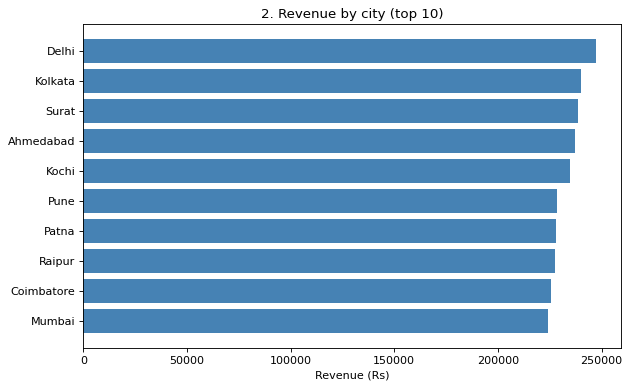

In [4]:
# 2. Revenue by city (top 10, by restaurant city)
city_rev = delivered.groupby("RestaurantCity")["FinalAmount"].sum().sort_values().tail(10)

plt.figure(figsize=(8, 5))
plt.barh(city_rev.index, city_rev.values, color="steelblue")
plt.title("2. Revenue by city (top 10)")
plt.xlabel("Revenue (Rs)")
save_chart("02_revenue_by_city")

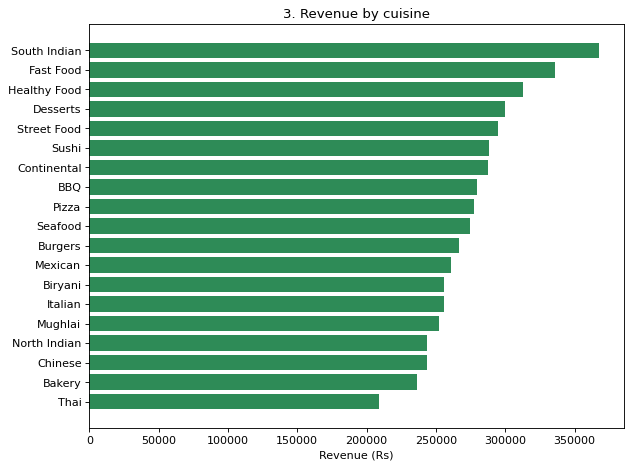

In [5]:
# 3. Revenue by cuisine
cuisine_rev = delivered.groupby("Cuisine")["FinalAmount"].sum().sort_values()

plt.figure(figsize=(8, 6))
plt.barh(cuisine_rev.index, cuisine_rev.values, color="seagreen")
plt.title("3. Revenue by cuisine")
plt.xlabel("Revenue (Rs)")
save_chart("03_revenue_by_cuisine")

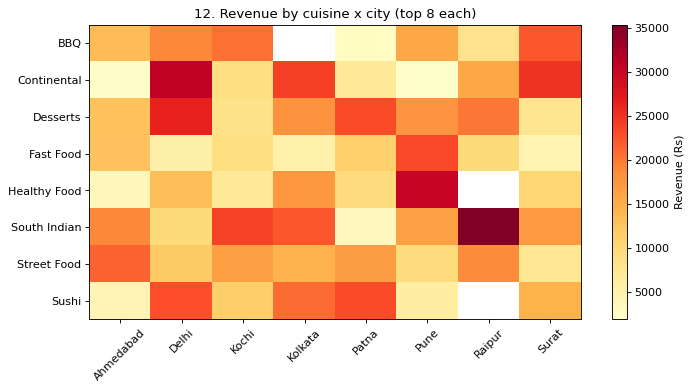

In [6]:
# 12. Revenue by cuisine x city (top 8 of each) - heatmap drawn with plain matplotlib
top_cuisines = cuisine_rev.tail(8).index
top_cities = city_rev.tail(8).index
grid = (
    delivered[delivered["Cuisine"].isin(top_cuisines) & delivered["RestaurantCity"].isin(top_cities)]
    .pivot_table(index="Cuisine", columns="RestaurantCity", values="FinalAmount", aggfunc="sum")
)

plt.figure(figsize=(9, 5))
plt.imshow(grid.values, cmap="YlOrRd", aspect="auto")
plt.colorbar(label="Revenue (Rs)")
plt.xticks(range(len(grid.columns)), grid.columns, rotation=45)
plt.yticks(range(len(grid.index)), grid.index)
plt.title("12. Revenue by cuisine x city (top 8 each)")
save_chart("12_revenue_cuisine_city")

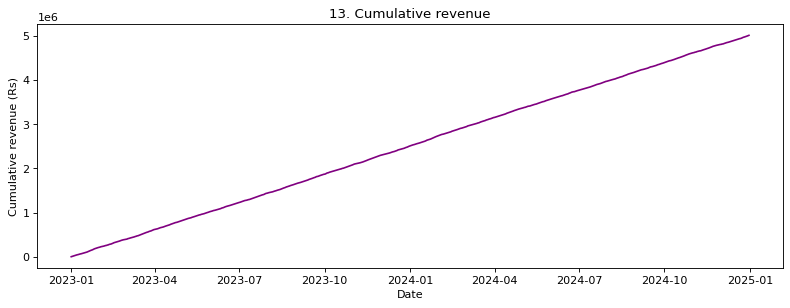

In [7]:
# 13. Cumulative revenue over time
daily = delivered.groupby("OrderDate")["FinalAmount"].sum().sort_index()

plt.figure(figsize=(10, 4))
plt.plot(daily.index, daily.cumsum(), color="purple")
plt.title("13. Cumulative revenue")
plt.xlabel("Date")
plt.ylabel("Cumulative revenue (Rs)")
save_chart("13_cumulative_revenue")

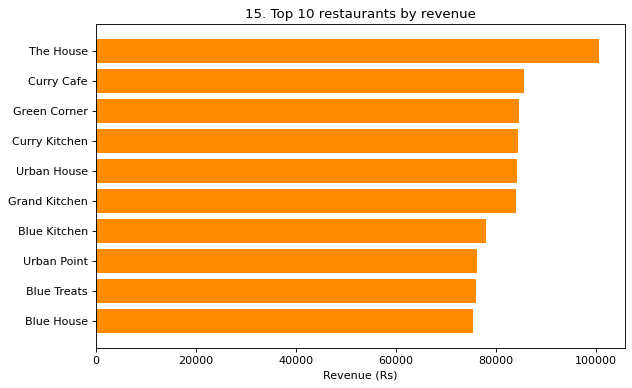

In [8]:
# 15. Top 10 restaurants by revenue
top_rest = (
    delivered.groupby("RestaurantName")["FinalAmount"].sum().sort_values().tail(10)
)

plt.figure(figsize=(8, 5))
plt.barh(top_rest.index, top_rest.values, color="darkorange")
plt.title("15. Top 10 restaurants by revenue")
plt.xlabel("Revenue (Rs)")
save_chart("15_top_restaurants")

**Takeaways (revenue):** delivered orders bring in about Rs 5.3 million over two years, spread quite
evenly across cities and months — no single city or month dominates. Cuisine is slightly more uneven
(South Indian and Fast Food lead), but the gaps are modest.

### Order behaviour

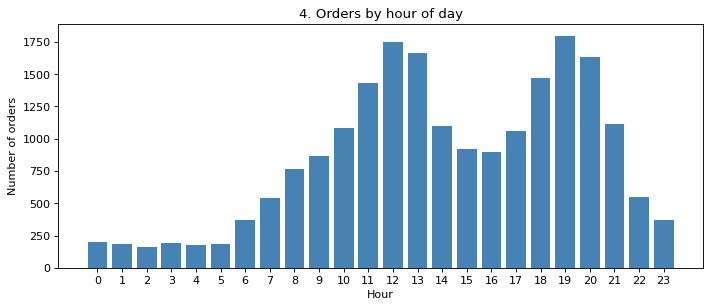

In [9]:
# 4. Orders by hour of day
by_hour = orders.groupby("OrderHour").size()

plt.figure(figsize=(9, 4))
plt.bar(by_hour.index, by_hour.values, color="steelblue")
plt.title("4. Orders by hour of day")
plt.xlabel("Hour")
plt.ylabel("Number of orders")
plt.xticks(range(0, 24))
save_chart("04_orders_by_hour")

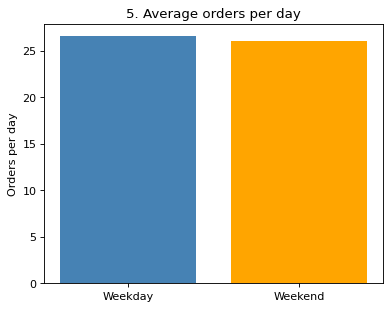

In [10]:
# 5. Weekday vs weekend - average orders PER DAY (weekdays have 5 days, weekends 2, so raw totals aren't comparable)
per_day = orders.groupby(["OrderDate", "IsWeekend"]).size().reset_index(name="Orders")
avg_per_day = per_day.groupby("IsWeekend")["Orders"].mean()

plt.figure(figsize=(5, 4))
plt.bar(["Weekday", "Weekend"], avg_per_day.values, color=["steelblue", "orange"])
plt.title("5. Average orders per day")
plt.ylabel("Orders per day")
save_chart("05_weekday_vs_weekend")

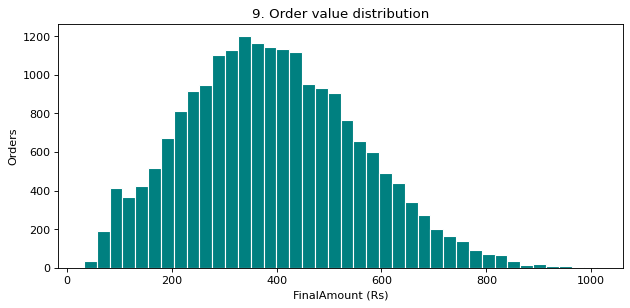

In [11]:
# 9. Order value distribution
plt.figure(figsize=(8, 4))
plt.hist(orders["FinalAmount"].dropna(), bins=40, color="teal", edgecolor="white")
plt.title("9. Order value distribution")
plt.xlabel("FinalAmount (Rs)")
plt.ylabel("Orders")
save_chart("09_order_value_distribution")

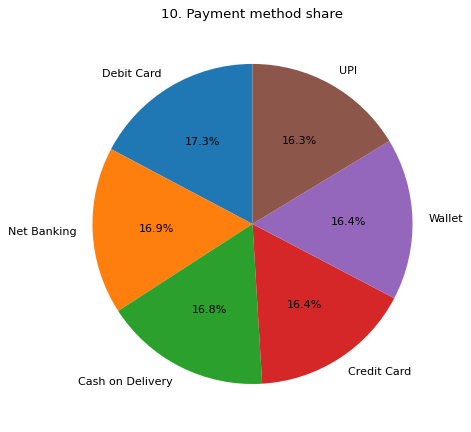

In [12]:
# 10. Payment method share
payment = orders["PaymentMethod"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(payment.values, labels=payment.index, autopct="%1.1f%%", startangle=90)
plt.title("10. Payment method share")
save_chart("10_payment_share")

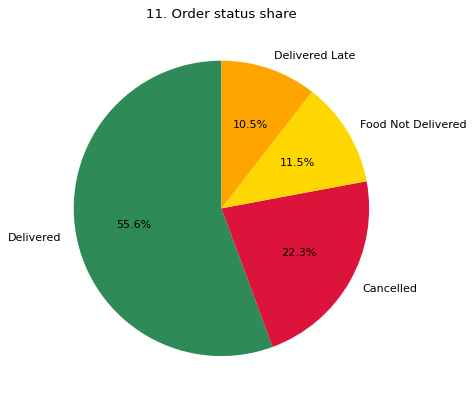

In [13]:
# 11. Order status share
status = orders["OrderStatus"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(status.values, labels=status.index, autopct="%1.1f%%", startangle=90,
        colors=["seagreen", "crimson", "gold", "orange"])
plt.title("11. Order status share")
save_chart("11_order_status_share")

**Takeaways (orders):** orders peak at lunch (12–1 pm) and dinner (7–8 pm), which matches the
`PeakHour` feature. Payment methods are split almost equally across six options. Only about
56% of orders are cleanly *Delivered* — 22% are cancelled, 11% never arrive and 10% arrive late.

### Delivery (delivered orders only)

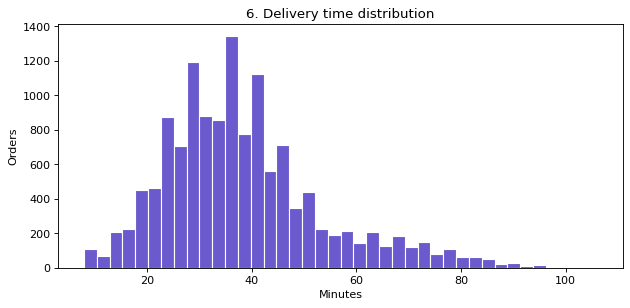

In [14]:
# 6. Delivery time distribution
plt.figure(figsize=(8, 4))
plt.hist(delivered["DeliveryTimeMinutes"].dropna(), bins=40, color="slateblue", edgecolor="white")
plt.title("6. Delivery time distribution")
plt.xlabel("Minutes")
plt.ylabel("Orders")
save_chart("06_delivery_time_distribution")

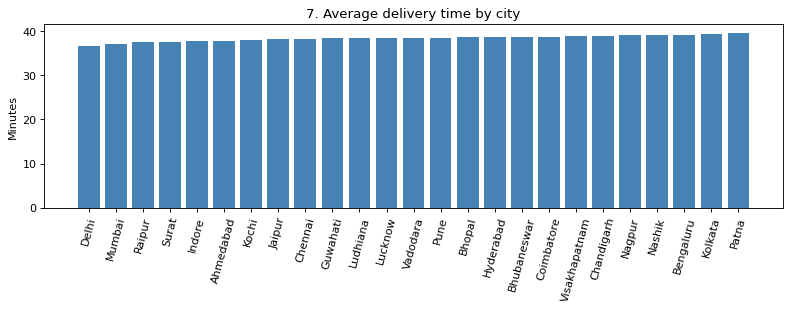

In [15]:
# 7. Average delivery time by city (customer city)
city_time = delivered.groupby("CustomerCity")["DeliveryTimeMinutes"].mean().sort_values()

plt.figure(figsize=(10, 4))
plt.bar(city_time.index, city_time.values, color="steelblue")
plt.title("7. Average delivery time by city")
plt.ylabel("Minutes")
plt.xticks(rotation=75)
save_chart("07_delivery_time_by_city")

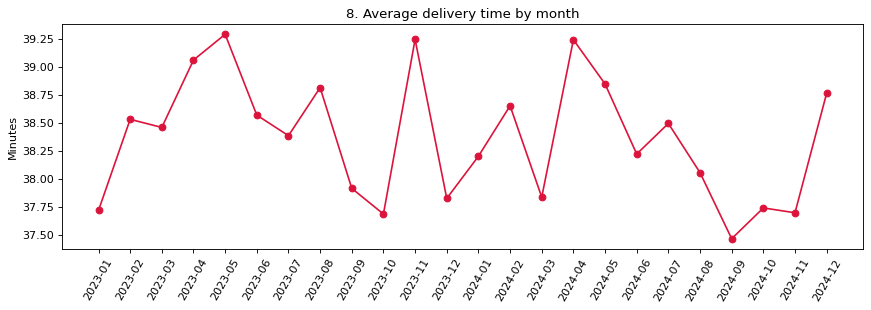

In [16]:
# 8. Delivery time trend (monthly average)
time_trend = delivered.groupby(delivered["OrderDate"].dt.to_period("M"))["DeliveryTimeMinutes"].mean()

plt.figure(figsize=(11, 4))
plt.plot(time_trend.index.astype(str), time_trend.values, marker="o", color="crimson")
plt.title("8. Average delivery time by month")
plt.ylabel("Minutes")
plt.xticks(rotation=60)
save_chart("08_delivery_time_trend")

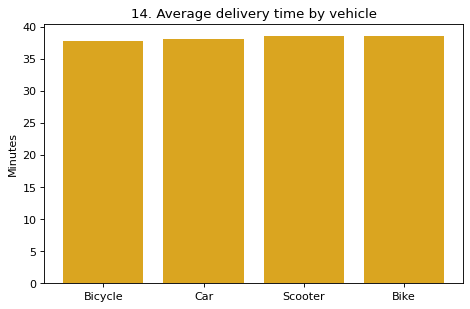

In [17]:
# 14. Delivery time by vehicle type
vehicle_time = delivered.groupby("VehicleType")["DeliveryTimeMinutes"].mean().sort_values()

plt.figure(figsize=(6, 4))
plt.bar(vehicle_time.index, vehicle_time.values, color="goldenrod")
plt.title("14. Average delivery time by vehicle")
plt.ylabel("Minutes")
save_chart("14_delivery_time_by_vehicle")

**Takeaways (delivery):** the typical delivery takes about 36–38 minutes, and the average barely
changes by city, month or vehicle type (all within a few minutes of each other). Delivery time barely differs
across any grouping we can slice by — the same flat pattern the ML models ran into (R² ≈ 0). The
exception is late vs on-time status (see chart 27).

# Part B — Seaborn (15 charts)

In [18]:
sns.set_theme(style="whitegrid")

### Relationships

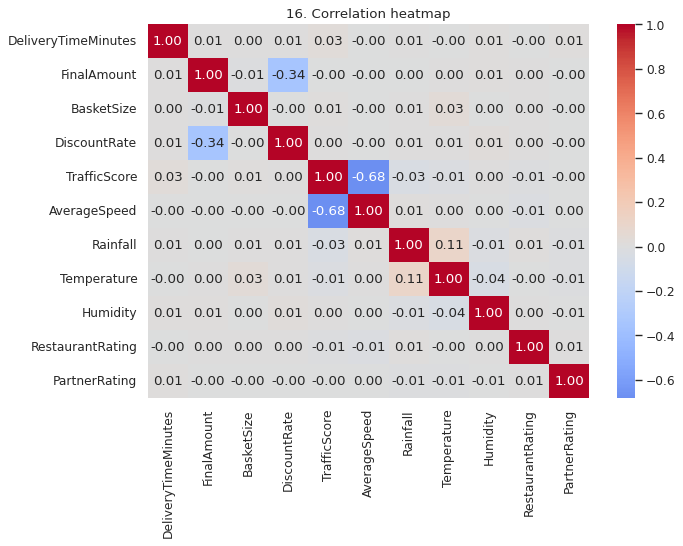

In [19]:
# 16. Correlation heatmap
numeric_cols = [
    "DeliveryTimeMinutes", "FinalAmount", "BasketSize", "DiscountRate", "TrafficScore",
    "AverageSpeed", "Rainfall", "Temperature", "Humidity", "RestaurantRating", "PartnerRating",
]
plt.figure(figsize=(9, 7))
sns.heatmap(orders[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("16. Correlation heatmap")
save_chart("16_correlation_heatmap")

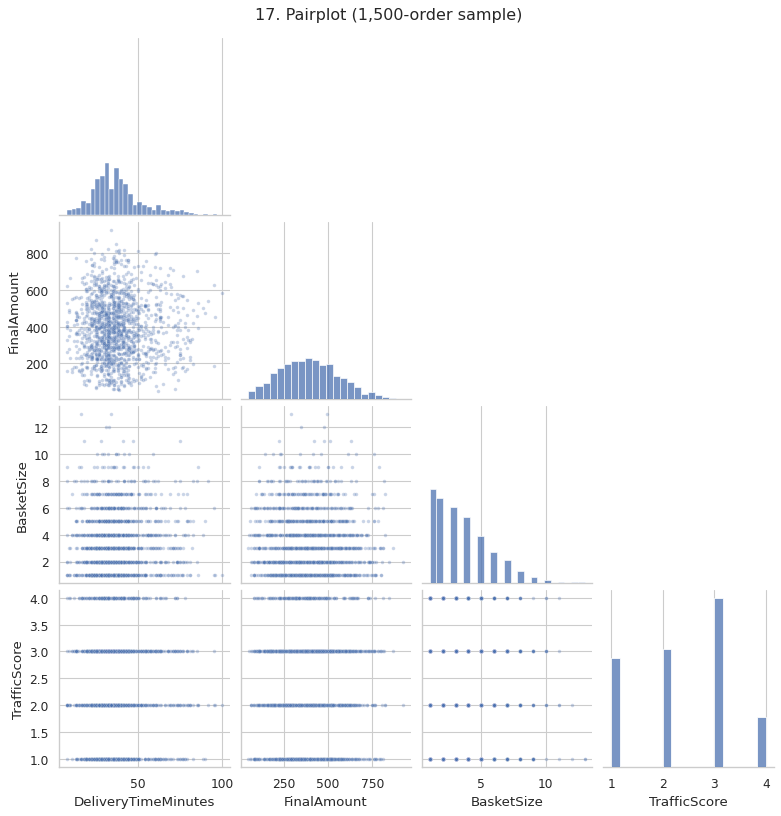

In [20]:
# 17. Pairplot (a random sample of delivered orders keeps it quick)
pair_cols = ["DeliveryTimeMinutes", "FinalAmount", "BasketSize", "TrafficScore"]
sample = delivered[pair_cols].dropna().sample(1500, random_state=42)

pair = sns.pairplot(sample, corner=True, plot_kws={"alpha": 0.3, "s": 10})
pair.figure.suptitle("17. Pairplot (1,500-order sample)", y=1.02)
pair.figure.savefig("../images/eda/17_pairplot.png", dpi=120, bbox_inches="tight")
plt.show()

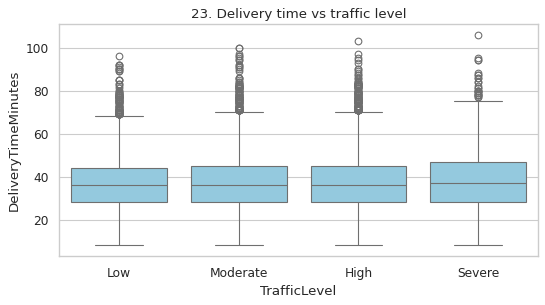

In [21]:
# 23. Delivery time vs traffic level
plt.figure(figsize=(7, 4))
sns.boxplot(data=delivered, x="TrafficLevel", y="DeliveryTimeMinutes",
            order=["Low", "Moderate", "High", "Severe"], color="skyblue")
plt.title("23. Delivery time vs traffic level")
save_chart("23_delivery_vs_traffic")

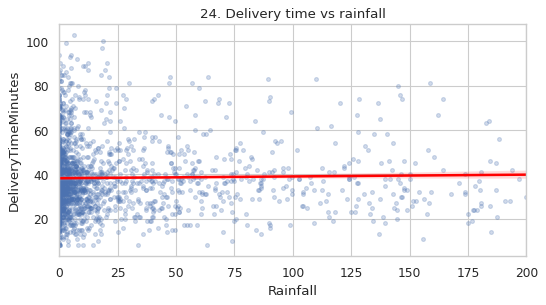

In [22]:
# 24. Delivery time vs rainfall (sample of orders that have a rainfall reading)
rain_sample = delivered.dropna(subset=["Rainfall", "DeliveryTimeMinutes"]).sample(2000, random_state=42)

plt.figure(figsize=(7, 4))
sns.regplot(data=rain_sample, x="Rainfall", y="DeliveryTimeMinutes",
            scatter_kws={"alpha": 0.25, "s": 12}, line_kws={"color": "red"})
plt.xlim(0, 200)
plt.title("24. Delivery time vs rainfall")
save_chart("24_delivery_vs_rainfall")

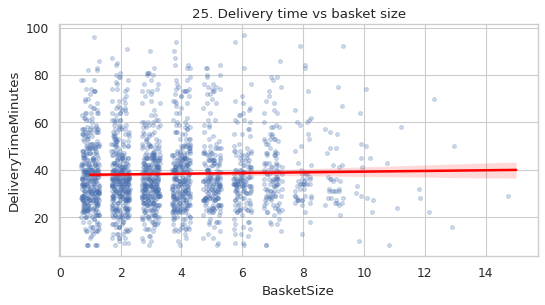

In [23]:
# 25. Delivery time vs basket size
basket_sample = delivered.dropna(subset=["BasketSize", "DeliveryTimeMinutes"]).sample(2000, random_state=42)

plt.figure(figsize=(7, 4))
sns.regplot(data=basket_sample, x="BasketSize", y="DeliveryTimeMinutes",
            x_jitter=0.3, scatter_kws={"alpha": 0.25, "s": 12}, line_kws={"color": "red"})
plt.title("25. Delivery time vs basket size")
save_chart("25_delivery_vs_basket")

**Takeaways (relationships):** almost every correlation with delivery time is 0.03 or lower — traffic,
rain, basket size, ratings and weather all have essentially no linear link to how long delivery takes.
The two strong relationships are structural: `AverageSpeed` falls as `TrafficScore` rises (−0.68) and
`DiscountRate` falls as order value rises (−0.34, because it is a share of the bill).

### Categories and distributions

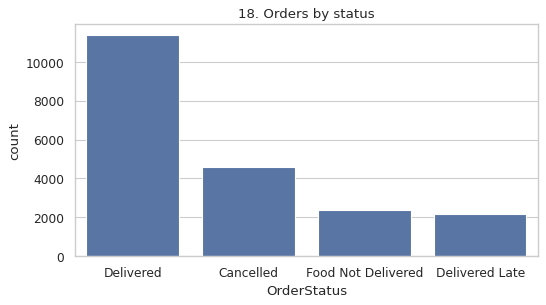

In [24]:
# 18. Order status countplot
plt.figure(figsize=(7, 4))
sns.countplot(data=orders, x="OrderStatus", order=orders["OrderStatus"].value_counts().index)
plt.title("18. Orders by status")
save_chart("18_status_countplot")

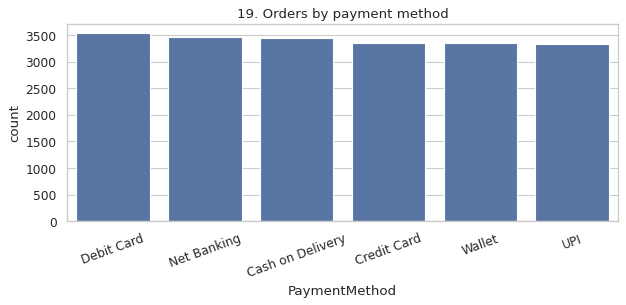

In [25]:
# 19. Payment method countplot
plt.figure(figsize=(8, 4))
sns.countplot(data=orders, x="PaymentMethod", order=orders["PaymentMethod"].value_counts().index)
plt.title("19. Orders by payment method")
plt.xticks(rotation=20)
save_chart("19_payment_countplot")

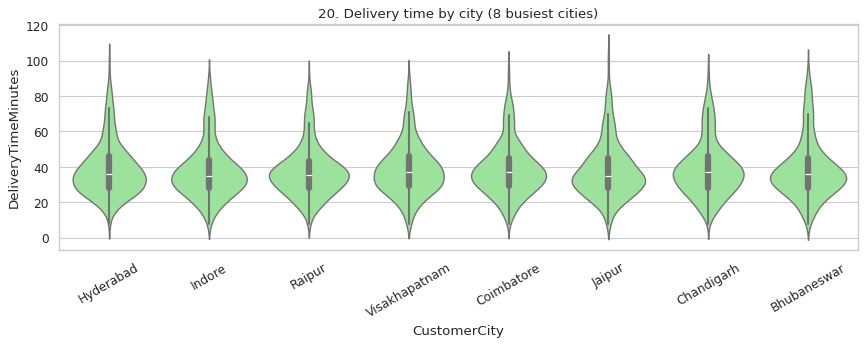

In [26]:
# 20. Delivery time violin for the 8 busiest customer cities
busy_cities = delivered["CustomerCity"].value_counts().head(8).index

plt.figure(figsize=(11, 4.5))
sns.violinplot(data=delivered[delivered["CustomerCity"].isin(busy_cities)],
               x="CustomerCity", y="DeliveryTimeMinutes", color="lightgreen")
plt.title("20. Delivery time by city (8 busiest cities)")
plt.xticks(rotation=30)
save_chart("20_delivery_violin_city")

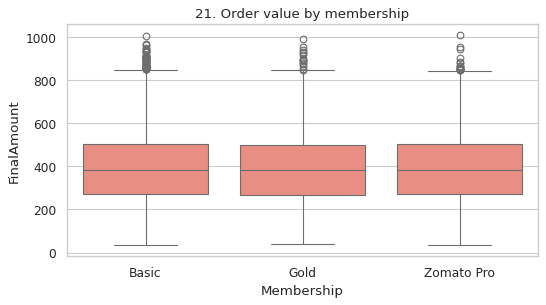

In [27]:
# 21. Order value by membership tier
plt.figure(figsize=(7, 4))
sns.boxplot(data=orders.dropna(subset=["Membership"]), x="Membership", y="FinalAmount",
            order=["Basic", "Gold", "Zomato Pro"], color="salmon")
plt.title("21. Order value by membership")
save_chart("21_order_value_membership")

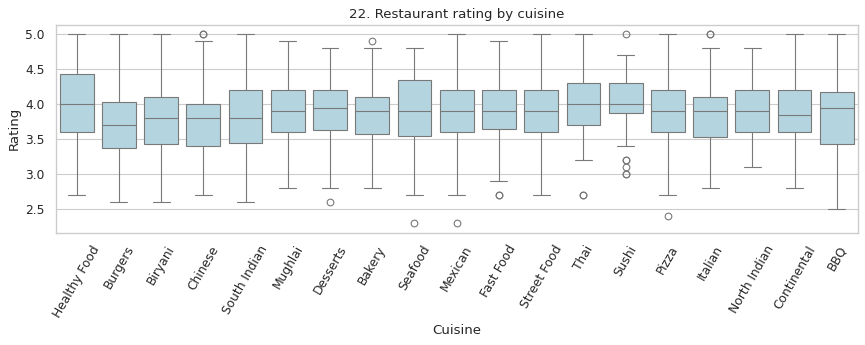

In [28]:
# 22. Restaurant rating by cuisine (one point per restaurant)
plt.figure(figsize=(11, 4.5))
sns.boxplot(data=restaurants, x="Cuisine", y="Rating", color="lightblue")
plt.title("22. Restaurant rating by cuisine")
plt.xticks(rotation=60)
save_chart("22_rating_by_cuisine")

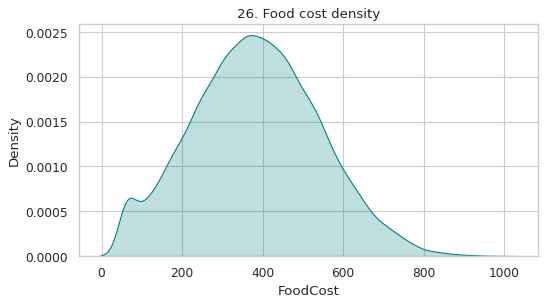

In [29]:
# 26. Food cost KDE
plt.figure(figsize=(7, 4))
sns.kdeplot(data=orders, x="FoodCost", fill=True, color="teal")
plt.title("26. Food cost density")
save_chart("26_food_cost_kde")

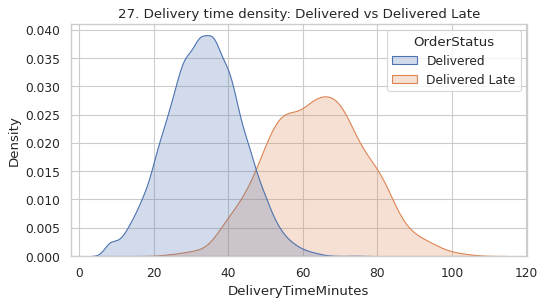

In [30]:
# 27. Delivery time KDE - on-time vs late deliveries
plt.figure(figsize=(7, 4))
sns.kdeplot(data=delivered, x="DeliveryTimeMinutes", hue="OrderStatus", fill=True, common_norm=False)
plt.title("27. Delivery time density: Delivered vs Delivered Late")
save_chart("27_delivery_time_kde")

**Takeaways (distributions):** order value looks the same for every membership tier, and restaurant
ratings look similar across cuisines. Chart 27 is the most important one here: *Delivered Late* orders
average about 64 minutes versus about 34 for normal deliveries, so the delivery-time distribution has a
long right tail made up almost entirely of late orders. About 16% of delivered orders are late.

### Customers and cancellations

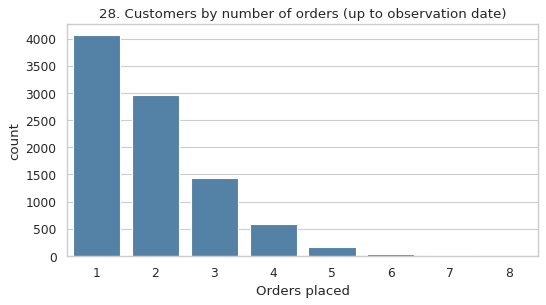

In [31]:
# 28. Customer order count distribution
plt.figure(figsize=(7, 4))
sns.countplot(data=customers, x="TotalOrders", color="steelblue")
plt.title("28. Customers by number of orders (up to observation date)")
plt.xlabel("Orders placed")
save_chart("28_customer_order_count")

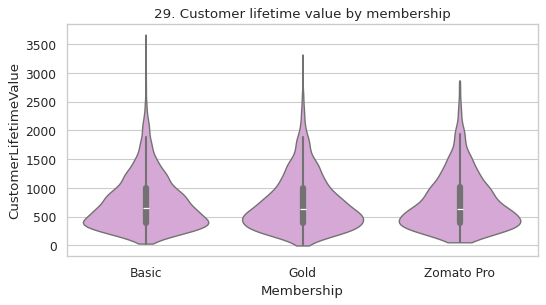

In [32]:
# 29. Customer lifetime value by membership
plt.figure(figsize=(7, 4))
sns.violinplot(data=customers.dropna(subset=["Membership"]), x="Membership", y="CustomerLifetimeValue",
               order=["Basic", "Gold", "Zomato Pro"], color="plum", cut=0)
plt.title("29. Customer lifetime value by membership")
save_chart("29_clv_by_membership")

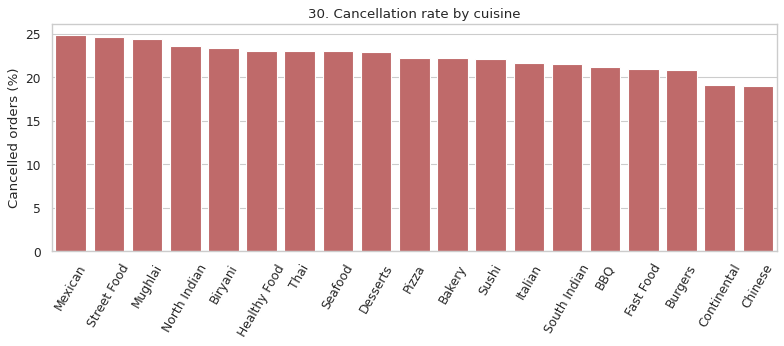

In [33]:
# 30. Cancellation rate by cuisine
orders["IsCancelled"] = (orders["OrderStatus"] == "Cancelled").astype(int)
cancel_rate = orders.groupby("Cuisine")["IsCancelled"].mean().mul(100).sort_values(ascending=False)

plt.figure(figsize=(10, 4.5))
sns.barplot(x=cancel_rate.index, y=cancel_rate.values, color="indianred")
plt.title("30. Cancellation rate by cuisine")
plt.ylabel("Cancelled orders (%)")
plt.xlabel("")
plt.xticks(rotation=60)
save_chart("30_cancellation_by_cuisine")

**Takeaways (customers):** customers order rarely — most have only 1–2 orders — which is why churn
modelling was hard. Lifetime value is essentially the same across membership tiers. Cancellation
rates run from about 19% (Chinese) to 25% (Mexican); these differences are modest.

## Chart checklist

In [34]:
import os
files = sorted(os.listdir("../images/eda"))
print(len(files), "charts saved in images/eda/")

30 charts saved in images/eda/


## Summary of insights

1. **Revenue is evenly spread** — about Rs 5.3M from delivered orders, with no dominant city, month or cuisine.
2. **Demand peaks at lunch and dinner** (12–1 pm and 7–8 pm) → the natural windows for extra delivery capacity.
3. **A third of orders don't complete cleanly:** 22% cancelled, 11% not delivered, 10% late. This is the biggest business problem visible in the data.
4. **Delivery time is remarkably uniform** — traffic, rain, vehicle, city and basket size barely move it (correlations ≤ 0.03).
5. **Delivery time is a two-part story** — normal deliveries average ~34 min, late ones ~64 min (16% of delivered orders). Late rate rises only mildly with traffic (14% Low → 18% Severe), so the big swings are not explained by the fields we have. This is why the delivery-time model struggled.
6. **Membership tiers look identical** in order value and lifetime value — no visible spending premium for Gold / Pro.
7. **Customers are low-frequency** (1–2 orders on average), limiting what customer-level models can learn.

**Limitations:** ~1,170 orders have no valid date (excluded from time charts); ~46% of orders have no
weather/traffic reading; restaurant-to-customer distance is unavailable (see `feature_dictionary.md`).